In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.09454448/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# Component 1

Enter measurements for species

In [14]:
logN_dict = {'HI':'14.53, -0.08, +0.08',
            'HeI':'<12.99',
            'CII':'<13.20',
            'CIII':'>13.41, 0.68',
            'CIV':'13.89, -0.03, +0.03',
            'NII':'<13.38',
            'NIV':'13.03,  -0.11, +0.11',
            'NV':'<13.43',
            'OII':'<13.36',
            'OIII':'14.17, -0.05, +0.05',
            'OIV':'14.71, -0.12, +0.12',
            'NeVI':'<13.62',
            'NeVIII':'<13.66',
            'MgII':'<11.36',
            'MgX':'<13.76',
            'AlII':'<11.21',
            'AlIII':'<11.53',
            'SiII':'<12.23',
            'SiIII':'<12.07',
            'SIV':'<12.69',
            'SV':'<12.25',
            'SVI':'<13.41',
            'FeII':'<11.77'}

Try out a solution including sub-solar [C/O], [N/O], [S/O]

In [15]:
logN_HI_test = 14.53
log_hdens_test = -3.6 #-1.7  
O_H_test = 0.1 #-1.0  
C_O_test = -0.5
N_O_test = -0.9
S_O_test = -0.5
log_metals_test = get_metal_abundance(O_H_test, {'C': C_O_test, 'N': N_O_test, 'S': S_O_test})

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp, {'C': C_O_test, 
                                                                            'N': N_O_test,
                                                                            'S': S_O_test})

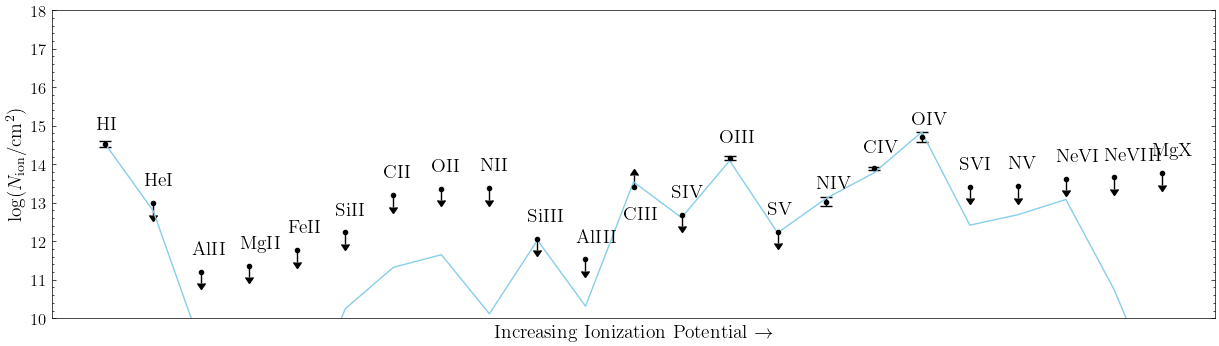

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Define overridden priors, likelihood, and posterior

In [18]:
def lambda_log_prior(params):
    
    # Only parameters being varied
    logN_HI, log_hdens, O_H, C_O, N_O, S_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {'C': C_O, 'N': N_O, 'S': S_O}])
    
    if S_O < -3 or N_O < -2:
        return -np.inf
    
    # Call the original prior function on the full set of parameters
    return log_prior(params_full)

In [19]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    logN_HI, log_hdens, O_H, C_O, N_O, S_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {'C': C_O, 'N': N_O, 'S': S_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [20]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Time to fit!

In [22]:
pos = np.array([logN_HI_test, log_hdens_test, O_H_test, C_O_test, N_O_test, S_O_test]) + 1e-6*np.random.randn(500, 6)
nwalkers, ndim = pos.shape

In [23]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [24]:
sampler.run_mcmc(pos, 500, progress=True);

 14%|█████▋                                    | 68/500 [03:05<19:22,  2.69s/it]/Users/thepoetoftwilight/Documents/CUBS/Code/cloudy_fitting/cloudy_fit_lib.py:686: RuntimeWarning: divide by zero encountered in log
  ll += np.log(integrate.simpson(x=lin_y_range, y=np.exp(-.5*(lin_y_range-10**y_bar)**2/sig_lin_y**2)))
100%|█████████████████████████████████████████| 500/500 [21:58<00:00,  2.64s/it]


In [25]:
flat_samples_subsolar = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['logN_HI', 'log_hdens', '[O/H]', '[C/O]', '[N/O]', '[S/O]'])
flat_samples_subsolar.to_csv(savedir+'c1_subsolar_flat.csv', index=False)

#flat_samples_subsolar = pd.read_csv(savedir+'c1_subsolar_flat.csv')

In [26]:
flat_samples_subsolar['[M/H]'] = [get_metal_abundance(flat_samples_subsolar.iloc[i]['[O/H]'], 
                                                   {'C': flat_samples_subsolar.iloc[i]['[C/O]'],
                                                    'N': flat_samples_subsolar.iloc[i]['[N/O]'],
                                                    'S': flat_samples_subsolar.iloc[i]['[S/O]']}) for 
                               i in range(len(flat_samples_subsolar))]

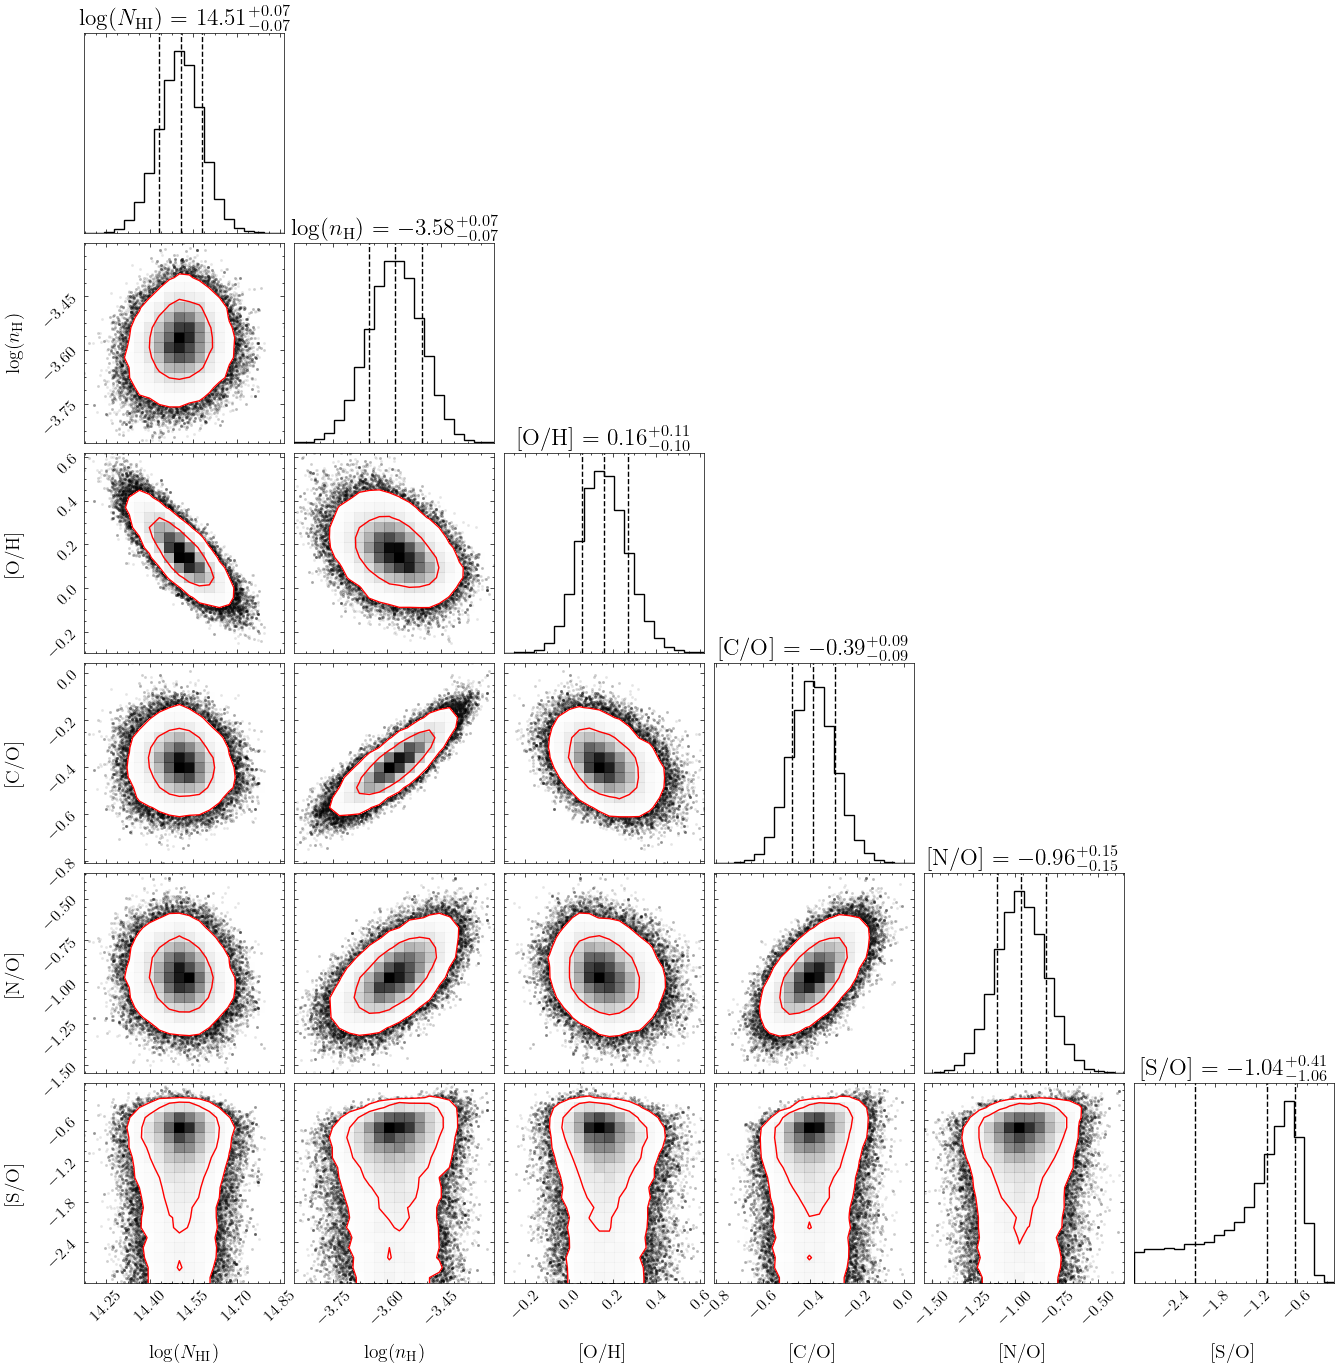

In [27]:
fig = corner.corner(
    flat_samples_subsolar.loc[:, ['logN_HI', 'log_hdens', '[O/H]', '[C/O]', '[N/O]', '[S/O]']], 
    quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_{\mathrm{HI}})$', r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', 
            r'$[\mathrm{C/O}]$', r'$[\mathrm{N/O}]$', r'$[\mathrm{S/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

(array([1.4000e+01, 5.2400e+02, 5.6470e+03, 3.0010e+04, 6.5768e+04,
        6.0186e+04, 2.8366e+04, 8.0050e+03, 1.3250e+03, 1.5500e+02]),
 array([-0.40265952, -0.31167073, -0.22068193, -0.12969313, -0.03870434,
         0.05228446,  0.14327325,  0.23426205,  0.32525084,  0.41623964,
         0.50722844]),
 <BarContainer object of 10 artists>)

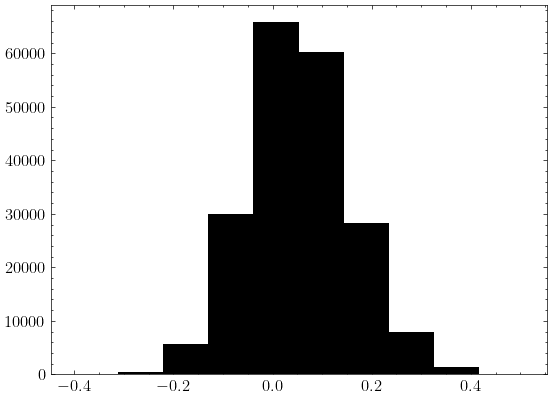

In [28]:
plt.hist(flat_samples_subsolar['[M/H]'])

In [29]:
hist, bins = np.histogram(flat_samples_subsolar['[S/O]'], bins=150, density=True)
centers = 10**(.5*(bins[1:]+bins[:-1]))

In [30]:
PDF = hist/integrate.trapz(x=centers, y=hist)

Text(0, 0.5, 'PDF')

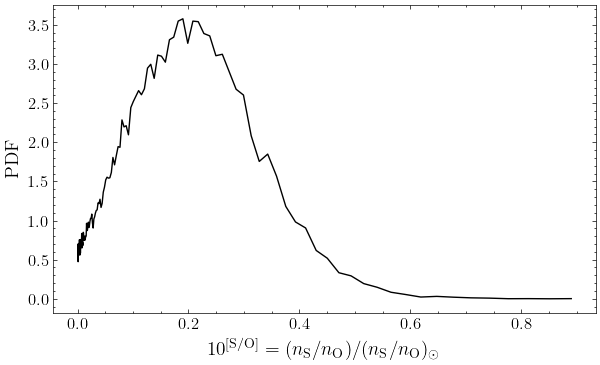

In [31]:
fig, ax = plt.subplots(1, figsize=(7, 4))

ax.plot(centers, PDF)
ax.set_xlabel(r'$10^{[\mathrm{S}/\mathrm{O}]}=(n_{\mathrm{S}}/n_{\mathrm{O}})/(n_{\mathrm{S}}/n_{\mathrm{O}})_{\odot}$')
ax.set_ylabel('PDF')

In [32]:
CDF = integrate.cumtrapz(x=centers, y=PDF, initial=0)/integrate.trapz(x=centers, y=PDF)

In [33]:
CDF_inv_interp = interpolate.interp1d(x=CDF, y=centers)

Text(0, 0.5, 'CDF')

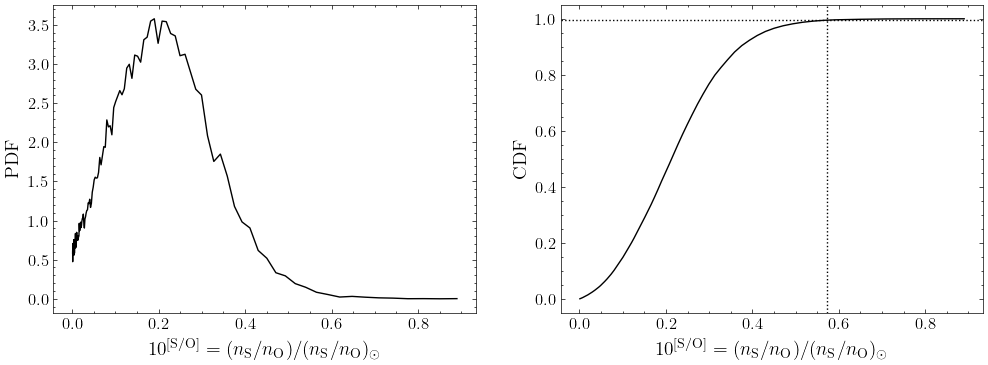

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(centers, PDF)
axes[0].set_xlabel(r'$10^{[\mathrm{S}/\mathrm{O}]}=(n_{\mathrm{S}}/n_{\mathrm{O}})/(n_{\mathrm{S}}/n_{\mathrm{O}})_{\odot}$')
axes[0].set_ylabel('PDF')

axes[1].plot(centers, CDF)
axes[1].axhline(0.995, linestyle=':')
axes[1].axvline(CDF_inv_interp(0.995), linestyle=':')
axes[1].set_xlabel(r'$10^{[\mathrm{S}/\mathrm{O}]}=(n_{\mathrm{S}}/n_{\mathrm{O}})/(n_{\mathrm{S}}/n_{\mathrm{O}})_{\odot}$')
axes[1].set_ylabel('CDF')

In [35]:
np.log10(CDF_inv_interp(0.995))

-0.24196716409855573

Overplot fit samples

In [36]:
sample_indices_subsolar = np.random.randint(low=0, high=len(flat_samples_subsolar), size=200)

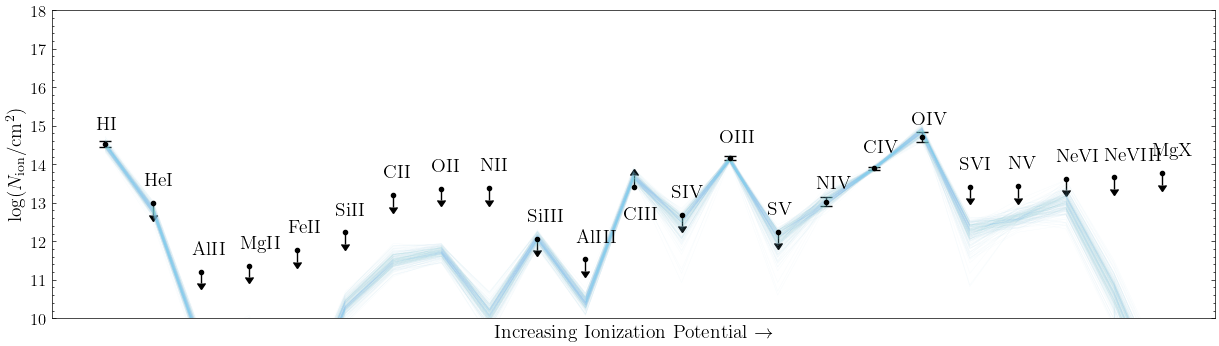

In [37]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_subsolar)):
    
    idx = sample_indices_subsolar[i]
    flat_samples_row = flat_samples_subsolar.iloc[i]
    logN_HI = flat_samples_row['logN_HI']
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['[M/H]']
    C_O = flat_samples_row['[C/O]']
    N_O = flat_samples_row['[N/O]']
    S_O = flat_samples_row['[S/O]']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI, log_hdens, 
                                         log_metals, species_logN_interp, {'C': C_O, 'N': N_O, 'S': S_O})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue', lw=.2, alpha=.1)

Plot the posterior for cloud size

In [38]:
flat_samples_subsolar['cloud_size_pc'] = (10**flat_samples_subsolar['logN_HI']/10**flat_samples_subsolar['log_hdens'])*3.24078e-19

Text(0, 0.5, 'Probability Density')

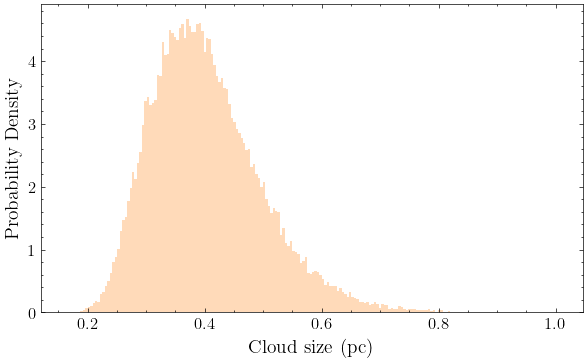

In [39]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_subsolar['cloud_size_pc'], bins=200, density=True, color='peachpuff')

ax.set_xlabel('Cloud size (pc)')
ax.set_ylabel('Probability Density')

# Component 2

In [41]:
logN_dict = {'HI':'<13.38',
            'HeI':'<12.93',
            'CII':'<13.10',
            'CIII':'<17.14',
            'CIV':'13.10, -0.16, +0.16',
            'NII':'<13.26',
            'NIV':'<12.73',
            'NV':'<13.30',
            'OII':'<13.24',
            'OIII':'13.68, -0.11, +0.11',
            'OIV':'14.21, -0.17, +0.17',
            'NeVI':'<13.53',
            'NeVIII':'<13.58',
            'MgII':'<11.26',
            'MgX':'<13.64',
            'AlII':'<11.10',
            'AlIII':'<11.44',
            'SiII':'<12.14',
            'SiIII':'<11.94',
            'SIV':'<12.59',
            'SV':'<12.15',
            'SVI':'<13.29',
            'FeII':'<11.66'}

Try out a solution including sub-solar [C/O], [N/O], [S/O]

In [93]:
logN_HI_test = 14.2
log_hdens_test = -3.3 #-1.7  
O_H_test = 0.1 #-1.0  
C_O_test = -0.5
N_O_test = -0.5
log_metals_test = get_metal_abundance(O_H_test, {'C': C_O_test, 'N': N_O_test})

In [94]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp, {'C': C_O_test, 
                                                                            'N': N_O_test})

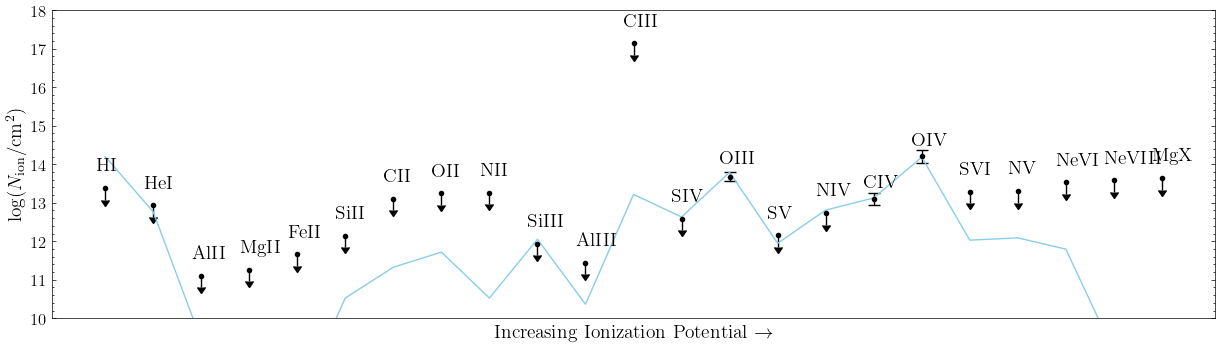

In [95]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Define overridden priors, likelihood, and posterior

In [96]:
def lambda_log_prior(params):
    
    # Only parameters being varied
    logN_HI, log_hdens, O_H, C_O, N_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {'C': C_O, 'N': N_O}])
    
    if N_O < -3:
        return -np.inf
    
    # Call the original prior function on the full set of parameters
    return log_prior(params_full)

In [97]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    logN_HI, log_hdens, O_H, C_O, N_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {'C': C_O, 'N': N_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [98]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Time to fit!

In [120]:
pos = np.array([logN_HI_test, log_hdens_test, O_H_test, C_O_test, N_O_test]) + 1e-6 * np.random.randn(500, 5)
nwalkers, ndim = pos.shape

In [121]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [122]:
sampler.run_mcmc(pos, 500, progress=True);

  8%|███▍                                      | 41/500 [01:51<20:51,  2.73s/it]/Users/thepoetoftwilight/Documents/CUBS/Code/cloudy_fitting/cloudy_fit_lib.py:686: RuntimeWarning: divide by zero encountered in log
  ll += np.log(integrate.simpson(x=lin_y_range, y=np.exp(-.5*(lin_y_range-10**y_bar)**2/sig_lin_y**2)))
100%|█████████████████████████████████████████| 500/500 [19:23<00:00,  2.33s/it]


In [123]:
flat_samples_subsolar = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['logN_HI', 'log_hdens', '[O/H]', '[C/O]', '[N/O]'])
flat_samples_subsolar.to_csv(savedir+'c2_subsolar_flat.csv', index=False)

#flat_samples_subsolar = pd.read_csv(savedir+'c2_subsolar_flat.csv')

In [124]:
flat_samples_subsolar['[M/H]'] = [get_metal_abundance(flat_samples_subsolar.iloc[i]['[O/H]'], 
                                                   {'C': flat_samples_subsolar.iloc[i]['[C/O]'],
                                                    'N': flat_samples_subsolar.iloc[i]['[N/O]']}) for 
                               i in range(len(flat_samples_subsolar))]

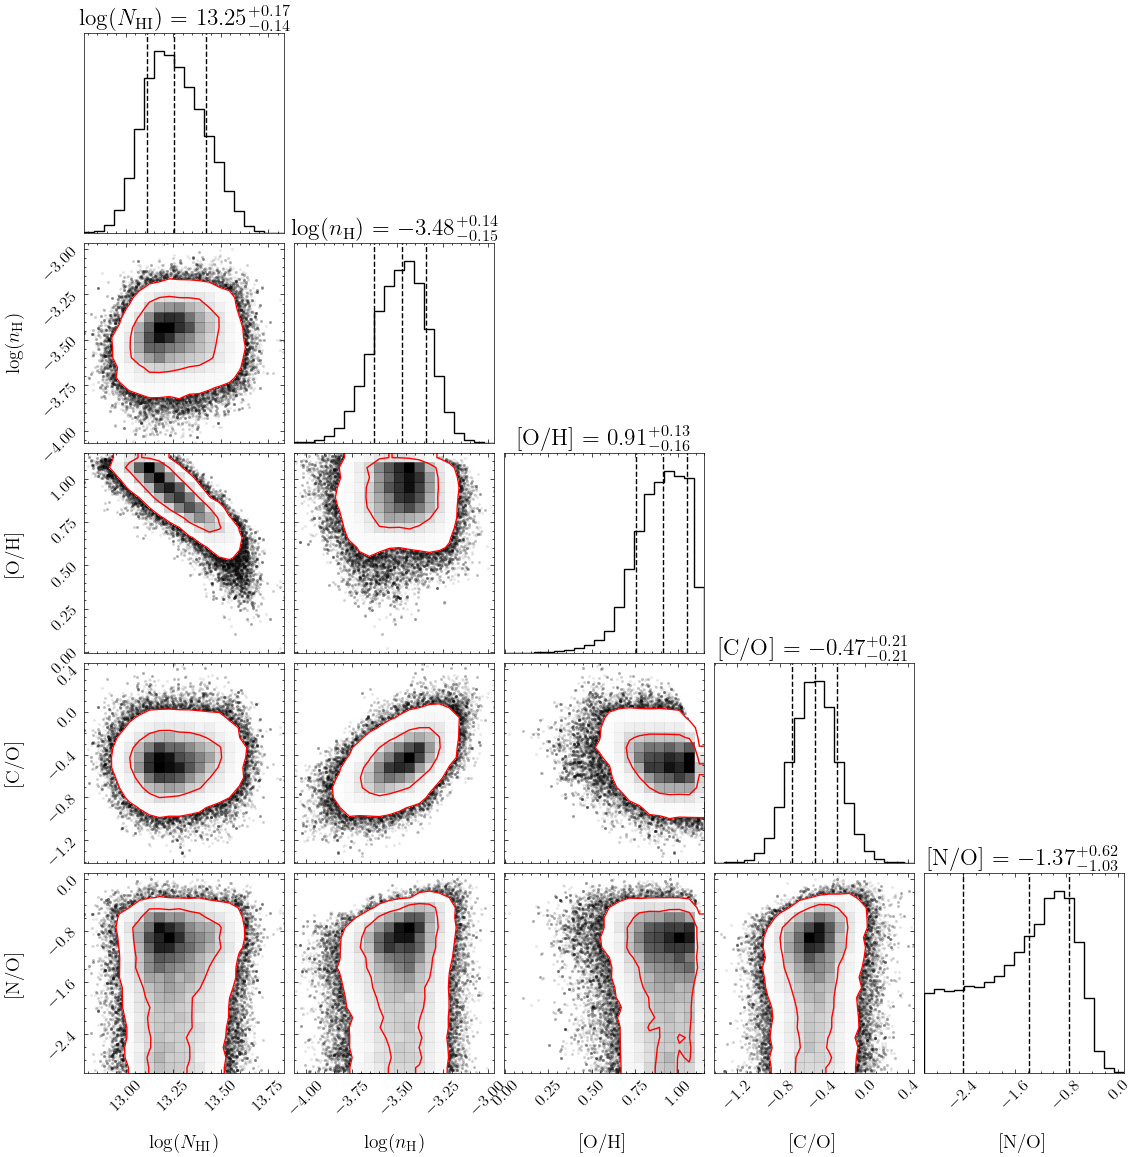

In [125]:
fig = corner.corner(
    flat_samples_subsolar.loc[:, ['logN_HI', 'log_hdens', '[O/H]', '[C/O]', '[N/O]']], 
    quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_{\mathrm{HI}})$', r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', 
            r'$[\mathrm{C/O}]$', r'$[\mathrm{N/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

(array([6.0000e+00, 3.2000e+01, 3.4000e+02, 1.0100e+03, 2.5470e+03,
        8.2850e+03, 2.8961e+04, 4.9373e+04, 5.4286e+04, 5.5160e+04]),
 array([-0.07134004,  0.03579374,  0.14292752,  0.2500613 ,  0.35719508,
         0.46432886,  0.57146264,  0.67859642,  0.7857302 ,  0.89286398,
         0.99999776]),
 <BarContainer object of 10 artists>)

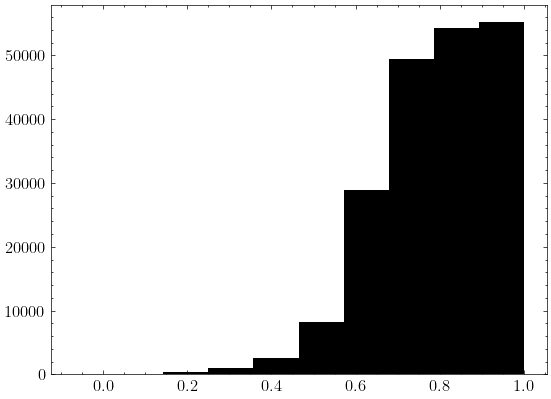

In [126]:
plt.hist(flat_samples_subsolar['[M/H]'])

In [127]:
hist, bins = np.histogram(flat_samples_subsolar['[N/O]'], bins=150, density=True)
centers = 10**(.5*(bins[1:]+bins[:-1]))

In [128]:
PDF = hist/integrate.trapz(x=centers, y=hist)

Text(0, 0.5, 'PDF')

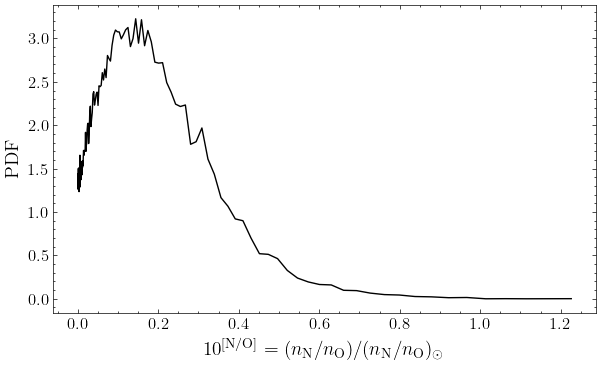

In [129]:
fig, ax = plt.subplots(1, figsize=(7, 4))

ax.plot(centers, PDF)
ax.set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}=(n_{\mathrm{N}}/n_{\mathrm{O}})/(n_{\mathrm{N}}/n_{\mathrm{O}})_{\odot}$')
ax.set_ylabel('PDF')

In [130]:
CDF = integrate.cumtrapz(x=centers, y=PDF, initial=0)/integrate.trapz(x=centers, y=PDF)

In [131]:
CDF_inv_interp = interpolate.interp1d(x=CDF, y=centers)

Text(0, 0.5, 'CDF')

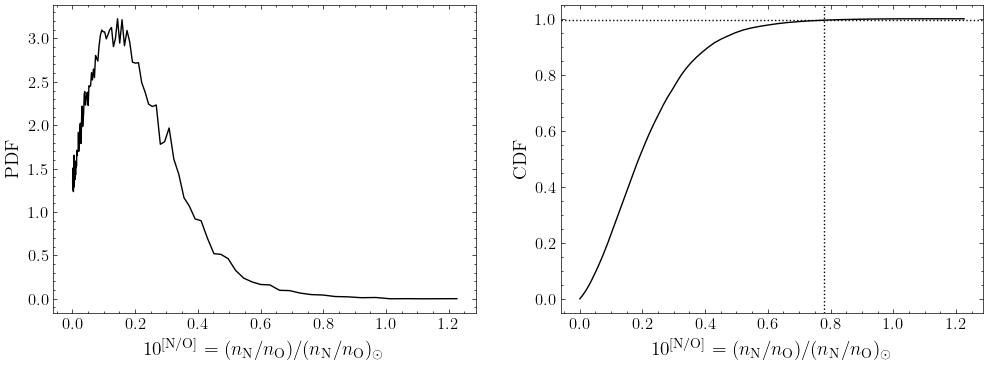

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(centers, PDF)
axes[0].set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}=(n_{\mathrm{N}}/n_{\mathrm{O}})/(n_{\mathrm{N}}/n_{\mathrm{O}})_{\odot}$')
axes[0].set_ylabel('PDF')

axes[1].plot(centers, CDF)
axes[1].axhline(0.995, linestyle=':')
axes[1].axvline(CDF_inv_interp(0.995), linestyle=':')
axes[1].set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}=(n_{\mathrm{N}}/n_{\mathrm{O}})/(n_{\mathrm{N}}/n_{\mathrm{O}})_{\odot}$')
axes[1].set_ylabel('CDF')

In [133]:
np.log10(CDF_inv_interp(0.995))

-0.10777544353951032

Overplot fit samples

In [134]:
sample_indices_subsolar = np.random.randint(low=0, high=len(flat_samples_subsolar), size=200)

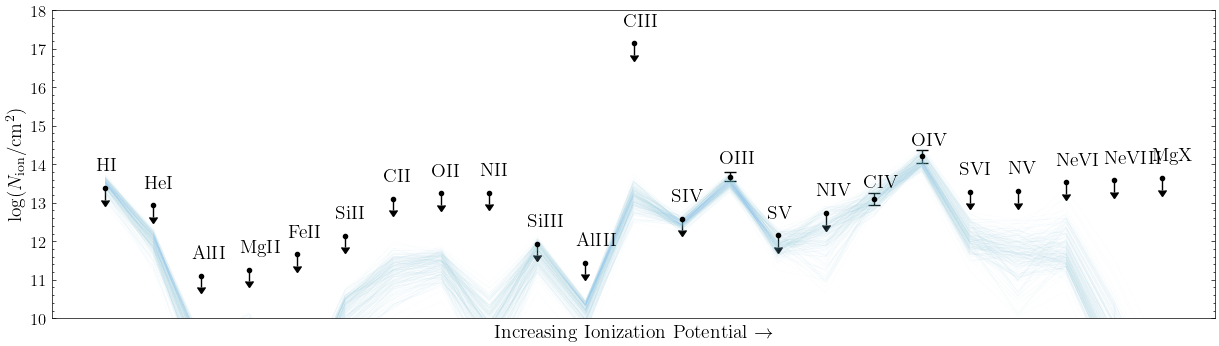

In [135]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_subsolar)):
    
    idx = sample_indices_subsolar[i]
    flat_samples_row = flat_samples_subsolar.iloc[i]
    logN_HI = flat_samples_row['logN_HI']
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['[M/H]']
    C_O = flat_samples_row['[C/O]']
    N_O = flat_samples_row['[N/O]']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI, log_hdens, 
                                         log_metals, species_logN_interp, {'C': C_O, 'N': N_O})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue', lw=.2, alpha=.1)

Plot the posterior for cloud size

In [136]:
flat_samples_subsolar['cloud_size_pc'] = (10**flat_samples_subsolar['logN_HI']/10**flat_samples_subsolar['log_hdens'])*3.24078e-19

Text(0, 0.5, 'Probability Density')

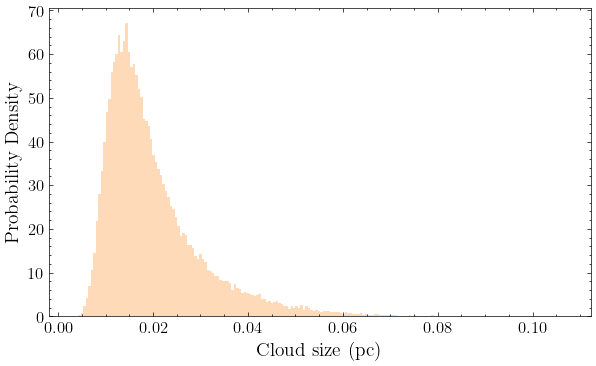

In [137]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_subsolar['cloud_size_pc'], bins=200, density=True, color='peachpuff')

ax.set_xlabel('Cloud size (pc)')
ax.set_ylabel('Probability Density')